# Identify Customer Segments

**Pipeline:**
1. Data Exploration & Preprocessing
2. Feature Engineering & Encoding
3. Scaling
4. PCA (Dimensionality Reduction)
5. K-Means Clustering
6. Market Profiling

---
## Step 0: Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

%matplotlib inline
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load datasets — update paths if running locally
azdias = pd.read_csv(r"Udacity_AZDIAS_Subset.csv", sep=';')
customers = pd.read_csv(r"Udacity_CUSTOMERS_Subset.csv", sep=';')
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

print('AZDIAS shape:   ', azdias.shape)
print('CUSTOMER shape: ', customers.shape)
print('feat_info shape:', feat_info.shape)

AZDIAS shape:    (891221, 85)
CUSTOMER shape:  (191652, 85)
feat_info shape: (85, 4)


---
## Step 1: Data Exploration

In [3]:
print(f'azdias head :')
print(azdias.head())

azdias head :
   AGER_TYP  ALTERSKATEGORIE_GROB  ANREDE_KZ  CJT_GESAMTTYP  \
0        -1                     2          1            2.0   
1        -1                     1          2            5.0   
2        -1                     3          2            3.0   
3         2                     4          2            2.0   
4        -1                     3          1            5.0   

   FINANZ_MINIMALIST  FINANZ_SPARER  FINANZ_VORSORGER  FINANZ_ANLEGER  \
0                  3              4                 3               5   
1                  1              5                 2               5   
2                  1              4                 1               2   
3                  4              2                 5               2   
4                  4              3                 4               1   

   FINANZ_UNAUFFAELLIGER  FINANZ_HAUSBAUER  ...  PLZ8_ANTG1  PLZ8_ANTG2  \
0                      5                 3  ...         NaN         NaN   
1                 

In [4]:
azdias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-nu

In [5]:
print(f'feat info  head {feat_info.head()}')

feat info  head               attribute information_level         type missing_or_unknown
0              AGER_TYP            person  categorical             [-1,0]
1  ALTERSKATEGORIE_GROB            person      ordinal           [-1,0,9]
2             ANREDE_KZ            person  categorical             [-1,0]
3         CJT_GESAMTTYP            person  categorical                [0]
4     FINANZ_MINIMALIST            person      ordinal               [-1]


In [6]:
feat_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   attribute           85 non-null     object
 1   information_level   85 non-null     object
 2   type                85 non-null     object
 3   missing_or_unknown  85 non-null     object
dtypes: object(4)
memory usage: 2.8+ KB


In [7]:
# Build unknown value mapping from feat_info
UNKNOWN_MAP = {}

for _, row in feat_info.iterrows():
    attr = row['attribute']
    unknown_str = row['missing_or_unknown']

    if unknown_str and unknown_str != '[]':
        values = unknown_str.strip('[]').split(',')

        cleaned_values = []
        for val in values:
            val = val.strip().replace("'", "").replace('"', '')

            try:
                val = int(val)
            except:
                pass

            if val != '':
                cleaned_values.append(val)

        UNKNOWN_MAP[attr] = cleaned_values

print(f'Features with "unknown" values:\n{UNKNOWN_MAP}')

Features with "unknown" values:
{'AGER_TYP': [-1, 0], 'ALTERSKATEGORIE_GROB': [-1, 0, 9], 'ANREDE_KZ': [-1, 0], 'CJT_GESAMTTYP': [0], 'FINANZ_MINIMALIST': [-1], 'FINANZ_SPARER': [-1], 'FINANZ_VORSORGER': [-1], 'FINANZ_ANLEGER': [-1], 'FINANZ_UNAUFFAELLIGER': [-1], 'FINANZ_HAUSBAUER': [-1], 'FINANZTYP': [-1], 'GEBURTSJAHR': [0], 'HEALTH_TYP': [-1, 0], 'LP_LEBENSPHASE_FEIN': [0], 'LP_LEBENSPHASE_GROB': [0], 'LP_FAMILIE_FEIN': [0], 'LP_FAMILIE_GROB': [0], 'LP_STATUS_FEIN': [0], 'LP_STATUS_GROB': [0], 'NATIONALITAET_KZ': [-1, 0], 'PRAEGENDE_JUGENDJAHRE': [-1, 0], 'RETOURTYP_BK_S': [0], 'SEMIO_SOZ': [-1, 9], 'SEMIO_FAM': [-1, 9], 'SEMIO_REL': [-1, 9], 'SEMIO_MAT': [-1, 9], 'SEMIO_VERT': [-1, 9], 'SEMIO_LUST': [-1, 9], 'SEMIO_ERL': [-1, 9], 'SEMIO_KULT': [-1, 9], 'SEMIO_RAT': [-1, 9], 'SEMIO_KRIT': [-1, 9], 'SEMIO_DOM': [-1, 9], 'SEMIO_KAEM': [-1, 9], 'SEMIO_PFLICHT': [-1, 9], 'SEMIO_TRADV': [-1, 9], 'SHOPPER_TYP': [-1], 'SOHO_KZ': [-1], 'TITEL_KZ': [-1, 0], 'VERS_TYP': [-1], 'ZABEOTYP': [-1

In [8]:
def apply_unknown_map(df, unknown_map):
    """Replace known unknown-encoding values with NaN, per column."""
    df = df.copy()
    for col, codes in unknown_map.items():
        if col in df.columns:
            df[col] = df[col].replace(codes, np.nan)
    return df

# Apply to azdias for exploration
azdias_recoded = apply_unknown_map(azdias, UNKNOWN_MAP)
print('Unknown values replaced with NaN.')

Unknown values replaced with NaN.


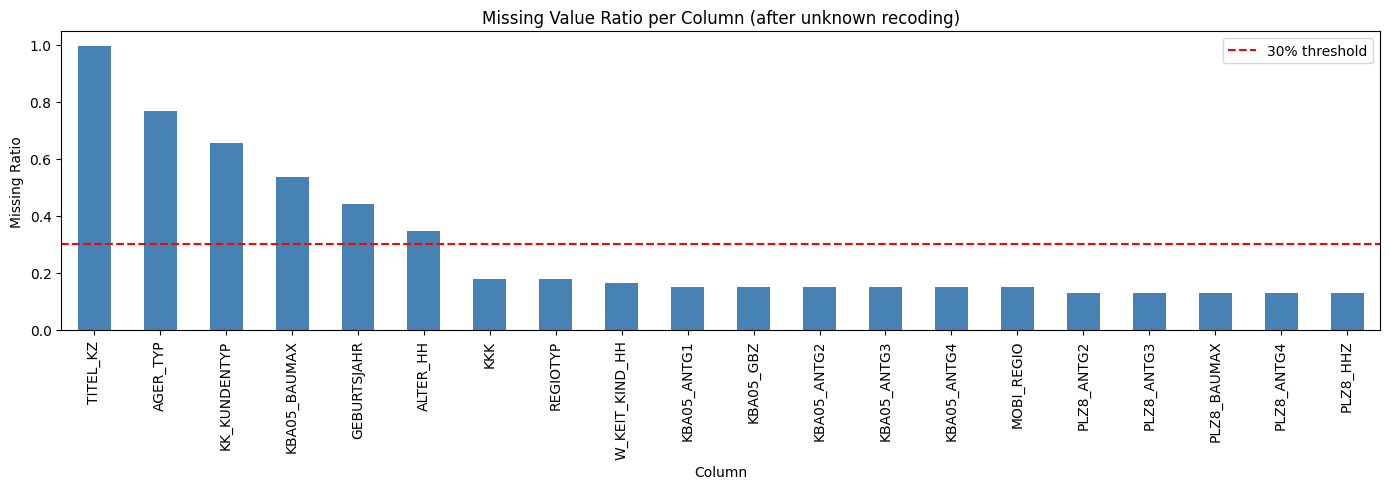


Columns with >30% missing:
TITEL_KZ        0.997576
AGER_TYP        0.769554
KK_KUNDENTYP    0.655967
KBA05_BAUMAX    0.534687
GEBURTSJAHR     0.440203
ALTER_HH        0.348137


In [9]:
# Missing ratio per column
missing_ratio = azdias_recoded.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
missing_ratio.head(20).plot(kind='bar', color='steelblue')
plt.axhline(y=0.30, color='red', linestyle='--', label='30% threshold')
plt.title('Missing Value Ratio per Column (after unknown recoding)')
plt.ylabel('Missing Ratio')
plt.xlabel('Column')
plt.legend()
plt.tight_layout()
plt.show()

print('\nColumns with >30% missing:')
print(missing_ratio[missing_ratio > 0.30].to_string())

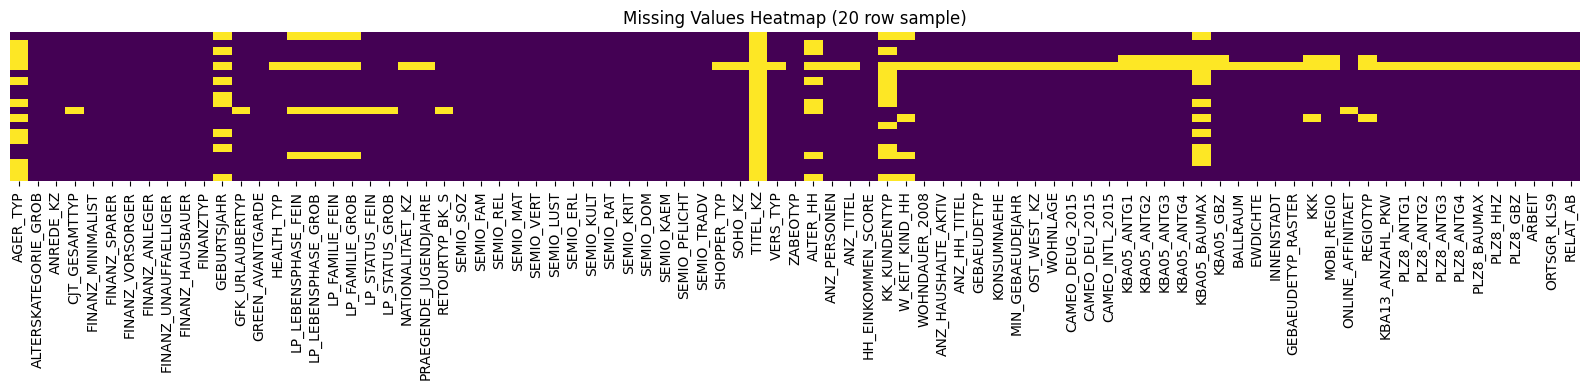

In [10]:
# Missing values heatmap on sample
sample = azdias_recoded.sample(20, random_state=42)
plt.figure(figsize=(16, 4))
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (20 row sample)')
plt.tight_layout()
plt.show()

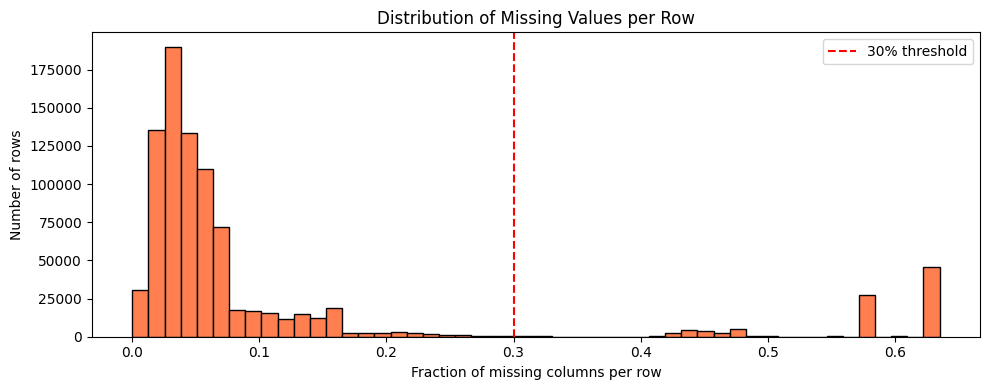

Rows with >30% missing: 93,837 (10.5%)


In [11]:
# Missing values per ROW distribution
row_missing = azdias_recoded.isnull().mean(axis=1)

plt.figure(figsize=(10, 4))
plt.hist(row_missing, bins=50, color='coral', edgecolor='black')
plt.axvline(x=0.30, color='red', linestyle='--', label='30% threshold')
plt.title('Distribution of Missing Values per Row')
plt.xlabel('Fraction of missing columns per row')
plt.ylabel('Number of rows')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Rows with >30% missing: {(row_missing > 0.30).sum():,} ({(row_missing > 0.30).mean():.1%})')

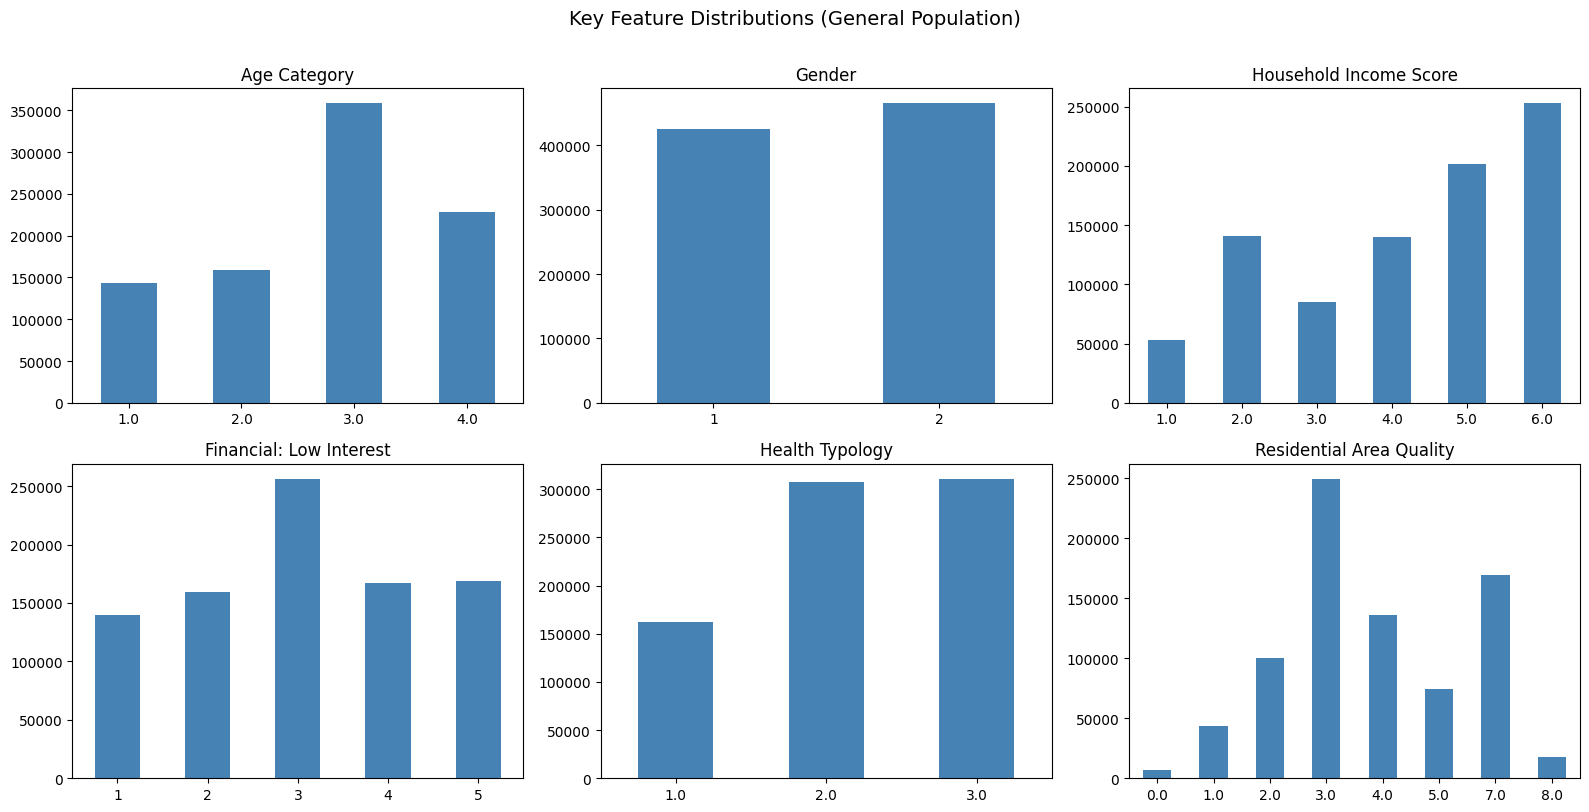

In [12]:
# Key feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

plot_features = [
    ('ALTERSKATEGORIE_GROB', 'Age Category'),
    ('ANREDE_KZ',            'Gender'),
    ('HH_EINKOMMEN_SCORE',   'Household Income Score'),
    ('FINANZ_MINIMALIST',    'Financial: Low Interest'),
    ('HEALTH_TYP',           'Health Typology'),
    ('WOHNLAGE',             'Residential Area Quality'),
]

for ax, (col, title) in zip(axes.flat, plot_features):
    if col in azdias_recoded.columns:
        azdias_recoded[col].dropna().value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Key Feature Distributions (General Population)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

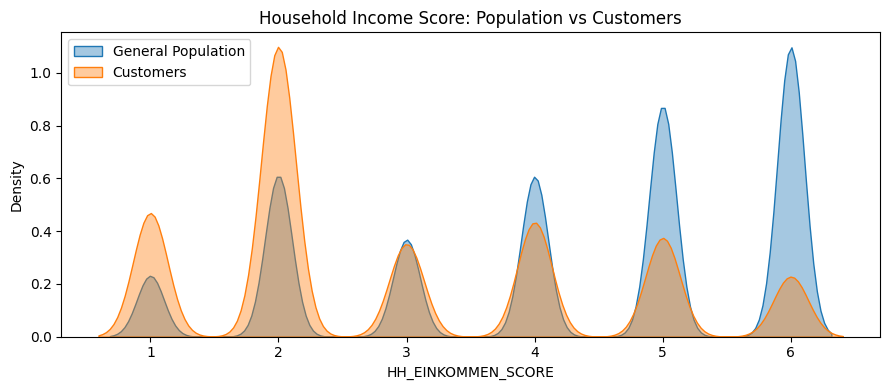

In [13]:
# Population vs Customers: Income comparison
customers_recoded = apply_unknown_map(customers, UNKNOWN_MAP)

plt.figure(figsize=(9, 4))
sns.kdeplot(azdias_recoded['HH_EINKOMMEN_SCORE'].dropna(),    label='General Population', fill=True, alpha=0.4)
sns.kdeplot(customers_recoded['HH_EINKOMMEN_SCORE'].dropna(), label='Customers',           fill=True, alpha=0.4)
plt.title('Household Income Score: Population vs Customers')
plt.xlabel('HH_EINKOMMEN_SCORE')
plt.legend()
plt.tight_layout()
plt.show()

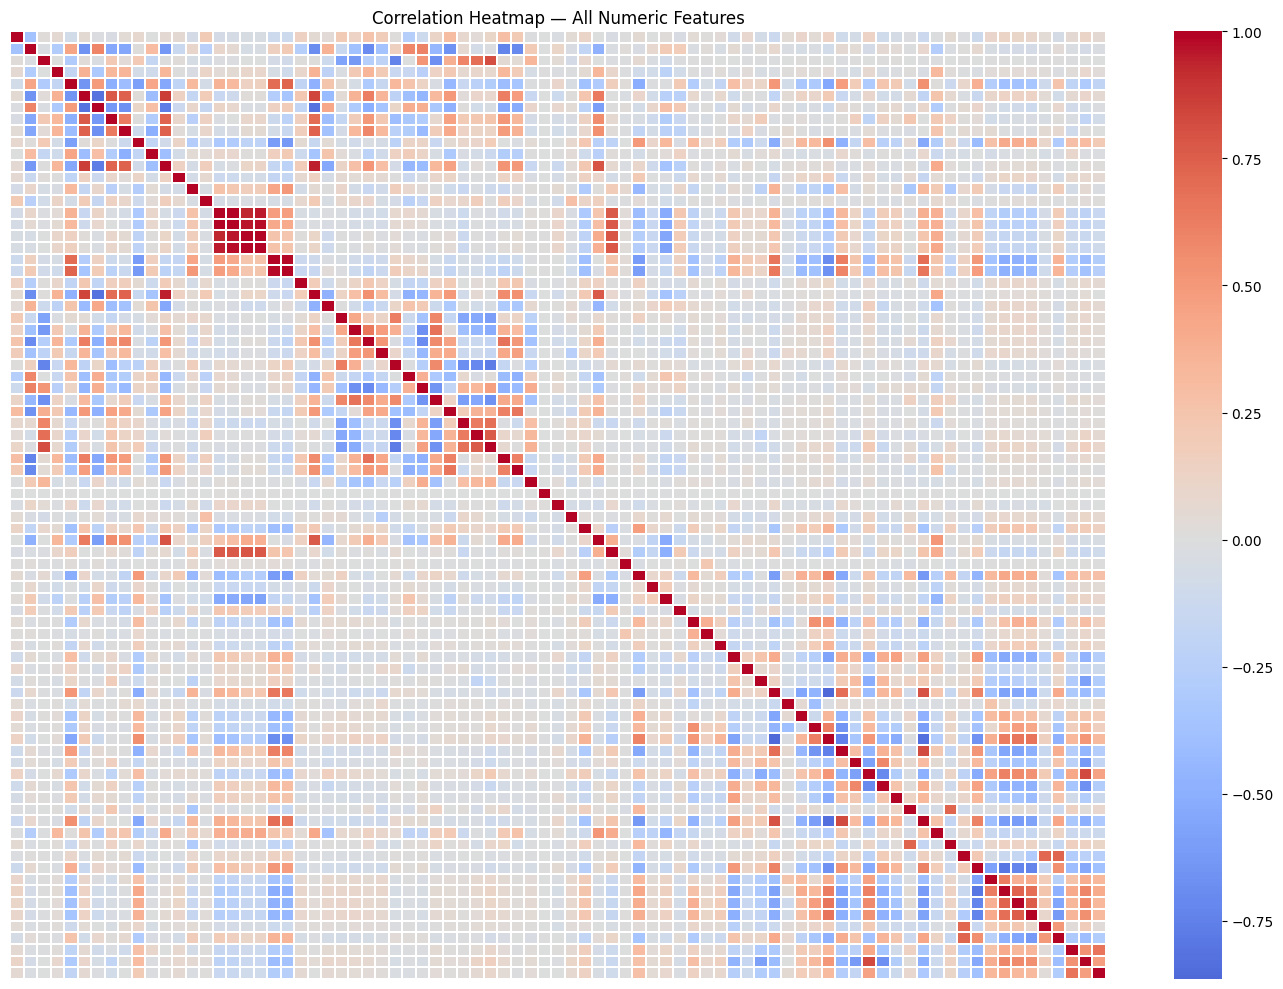

In [14]:
# Correlation heatmap
numeric_cols = azdias_recoded.select_dtypes(include=[np.number]).columns
corr = azdias_recoded[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=False, yticklabels=False)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

---
## Step 2: Preprocessing Pipeline

**Decisions made:**
- **Column threshold 30%:** Columns with >30% missing are dropped — too sparse to reliably impute.
- **Row threshold 30%:** Rows with >30% missing are dropped — these people lack enough demographic info to be useful.
- **PRAEGENDE_JUGENDJAHRE:** Split into `DECADE` (ordinal: 1=40s...6=90s) and `AVANTGARDE` (binary).
- **CAMEO_INTL_2015:** Split into `WEALTH` (1-5) and `LIFE_STAGE` (1-5).
- **Remaining NaN:** Filled with column median after encoding.

In [15]:
def engineer_features(df):
    """Feature engineering: split mixed-info columns."""
    df = df.copy()

    # PRAEGENDE_JUGENDJAHRE → DECADE + AVANTGARDE
    if 'PRAEGENDE_JUGENDJAHRE' in df.columns:
        avantgarde_vals = [2, 4, 6, 7, 9, 11, 13, 15]
        decade_map = {
            1: 1, 2: 1,
            3: 2, 4: 2,
            5: 3, 6: 3, 7: 3,
            8: 4, 9: 4,
            10: 5, 11: 5, 12: 5, 13: 5,
            14: 6, 15: 6
        }
        df['AVANTGARDE'] = df['PRAEGENDE_JUGENDJAHRE'].apply(
            lambda x: 1 if x in avantgarde_vals else (0 if pd.notnull(x) else np.nan)
        )
        df['DECADE'] = df['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
        df = df.drop('PRAEGENDE_JUGENDJAHRE', axis=1)

    # CAMEO_INTL_2015 → WEALTH + LIFE_STAGE
    if 'CAMEO_INTL_2015' in df.columns:
        df['CAMEO_INTL_2015'] = df['CAMEO_INTL_2015'].astype(str)
        df['WEALTH']     = pd.to_numeric(df['CAMEO_INTL_2015'].str[0], errors='coerce')
        df['LIFE_STAGE'] = pd.to_numeric(df['CAMEO_INTL_2015'].str[1], errors='coerce')
        df = df.drop('CAMEO_INTL_2015', axis=1)

    return df

In [16]:
# Identify categorical columns for encoding
categorical_cols = feat_info[feat_info['type'] == 'categorical']['attribute'].tolist()
binary_cols = []
multi_cols = []
for col in categorical_cols:
    if col in azdias.columns:
        if azdias[col].nunique(dropna=True) == 2:
            binary_cols.append(col)
        else:
            multi_cols.append(col)

print(f'Binary categoricals: {binary_cols}')
print(f'Multi-level categoricals: {multi_cols}')

Binary categoricals: ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'SOHO_KZ', 'OST_WEST_KZ']
Multi-level categoricals: ['AGER_TYP', 'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'TITEL_KZ', 'VERS_TYP', 'ZABEOTYP', 'KK_KUNDENTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']


In [17]:
def encode_features(df):
    """Encode ordinal and nominal columns."""
    df = df.copy()

    # OST_WEST_KZ: W=1, O=0
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'W': 1, 'O': 0})

    # Factorize binary features
    for col in binary_cols:
        if col in df.columns:
            df[col] = pd.factorize(df[col])[0]

    # One-hot encode multi-level categoricals
    multi_in_df = [col for col in multi_cols if col in df.columns]
    df = pd.get_dummies(df, columns=multi_in_df, dummy_na=True)
    return df

In [18]:
def full_pipeline(df, col_threshold=0.30, row_threshold=0.30):
    """Full preprocessing pipeline: recode → engineer → drop → encode → impute."""
    df = df.copy()

    # 1. Replace unknown encodings with NaN
    df = apply_unknown_map(df, UNKNOWN_MAP)

    # 2. Feature engineering
    df = engineer_features(df)

    # 3. Drop high-missing columns
    col_missing = df.isnull().mean()
    cols_to_drop = col_missing[col_missing >= col_threshold].index.tolist()
    df = df.drop(columns=cols_to_drop)
    print(f'  Dropped {len(cols_to_drop)} columns with >={col_threshold:.0%} missing')

    # 4. Drop high-missing rows
    row_missing = df.isnull().mean(axis=1)
    rows_before = len(df)
    df = df.loc[row_missing < row_threshold]
    print(f'  Dropped {rows_before - len(df):,} rows with >={row_threshold:.0%} missing')

    # 5. Encode
    df = encode_features(df)

    # 6. Final imputation with median
    df = df.fillna(df.median(numeric_only=True))

    print(f'  Final shape: {df.shape}')
    print(f'  NaN remaining: {df.isnull().sum().sum()}')
    return df

print('Pipeline functions defined.')

Pipeline functions defined.


In [19]:
print('Processing AZDIAS...')
azdias_clean = full_pipeline(azdias)

print('\nProcessing Customers...')
customers_clean = full_pipeline(customers)

# Align columns: customers should have the same columns as azdias
customers_clean = customers_clean.reindex(columns=azdias_clean.columns, fill_value=0)

print(f'\nFinal shape AZDIAS: {azdias_clean.shape}')
print(f'Final shape Customers: {customers_clean.shape}')
print(f'NaN in azdias_clean: {azdias_clean.isnull().sum().sum()}')
print(f'NaN in customers_clean: {customers_clean.isnull().sum().sum()}')

Processing AZDIAS...
  Dropped 6 columns with >=30% missing
  Dropped 93,376 rows with >=30% missing
  Final shape: (797845, 211)
  NaN remaining: 0

Processing Customers...
  Dropped 8 columns with >=30% missing
  Dropped 49,945 rows with >=30% missing
  Final shape: (141707, 208)
  NaN remaining: 0

Final shape AZDIAS: (797845, 211)
Final shape Customers: (141707, 211)
NaN in azdias_clean: 0
NaN in customers_clean: 0


---
## Step 3: Feature Scaling

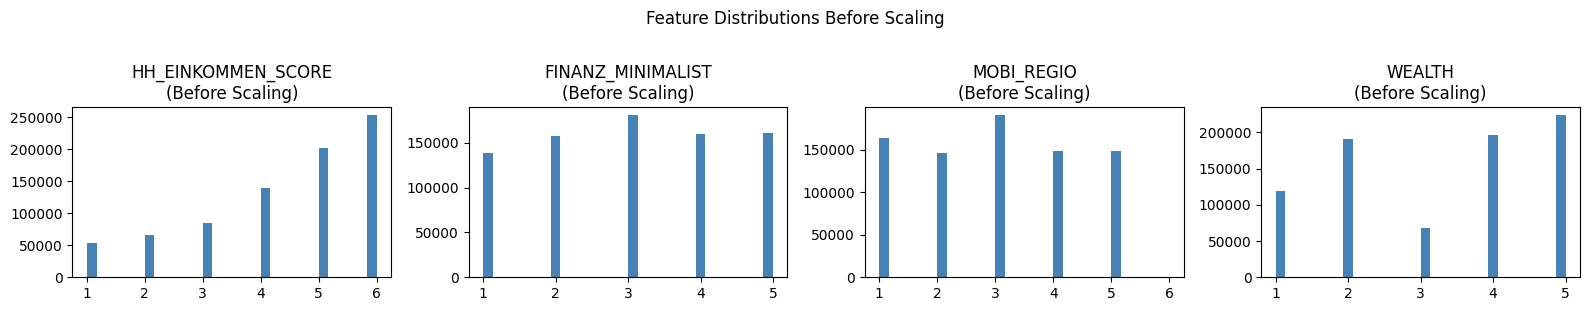

In [20]:
# Visualize a few features BEFORE scaling
viz_features = ['HH_EINKOMMEN_SCORE', 'FINANZ_MINIMALIST', 'MOBI_REGIO', 'WEALTH']
viz_features = [f for f in viz_features if f in azdias_clean.columns]

fig, axes = plt.subplots(1, len(viz_features), figsize=(16, 3))
for ax, col in zip(axes, viz_features):
    ax.hist(azdias_clean[col].dropna(), bins=30, color='steelblue', edgecolor='none')
    ax.set_title(f'{col}\n(Before Scaling)')
plt.suptitle('Feature Distributions Before Scaling', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Fit scaler on AZDIAS only — transform customers with the same fitted scaler
scaler = StandardScaler()
azdias_scaled    = scaler.fit_transform(azdias_clean)
customers_scaled = scaler.transform(customers_clean)

print(f'NaN in azdias_scaled:    {np.isnan(azdias_scaled).sum()}')
print(f'NaN in customers_scaled: {np.isnan(customers_scaled).sum()}')

NaN in azdias_scaled:    0
NaN in customers_scaled: 0


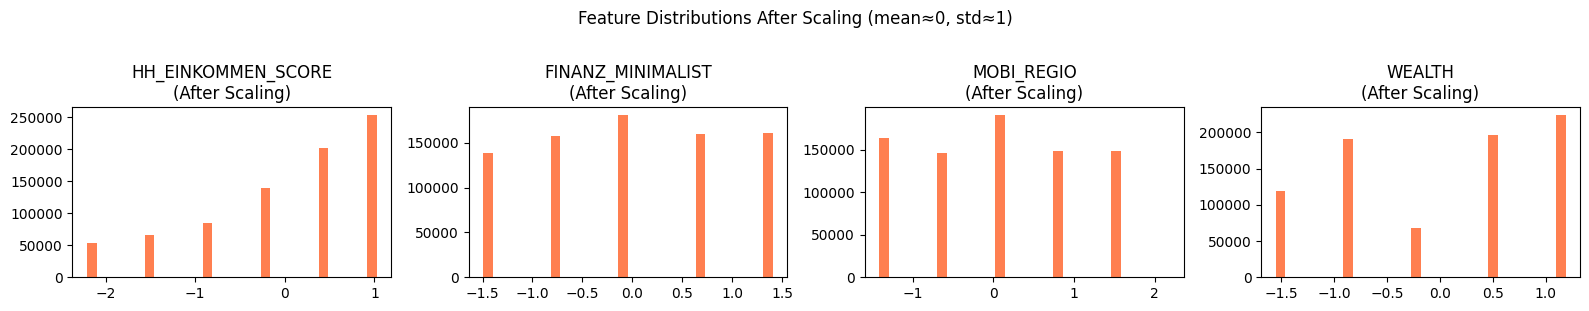

Mean of scaled features (should be ~0):
HH_EINKOMMEN_SCORE   -0.0
FINANZ_MINIMALIST     0.0
MOBI_REGIO            0.0
WEALTH                0.0
dtype: float64


In [22]:
# Visualize the same features AFTER scaling
azdias_scaled_df = pd.DataFrame(azdias_scaled, columns=azdias_clean.columns)

fig, axes = plt.subplots(1, len(viz_features), figsize=(16, 3))
for ax, col in zip(axes, viz_features):
    if col in azdias_scaled_df.columns:
        ax.hist(azdias_scaled_df[col].dropna(), bins=30, color='coral', edgecolor='none')
        ax.set_title(f'{col}\n(After Scaling)')
plt.suptitle('Feature Distributions After Scaling (mean≈0, std≈1)', y=1.02)
plt.tight_layout()
plt.show()

print('Mean of scaled features (should be ~0):')
print(azdias_scaled_df[viz_features].mean().round(4))

> Preprocessing Done -_^ ready for PCA and Clustering!

---
## Step 4: PCA — Implementation

In [23]:
# Fit PCA on scaled AZDIAS
pca = PCA()
pca.fit(azdias_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_

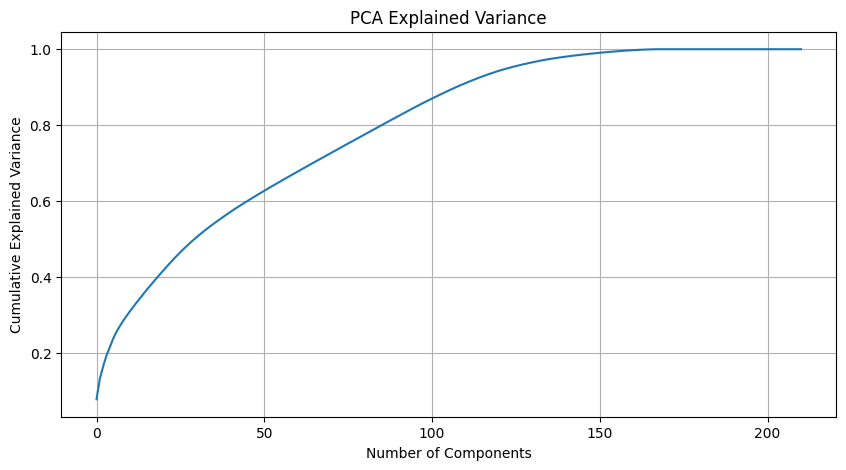

In [24]:
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

In [25]:
# Choose number of components to retain 90% variance
n_components = np.argmax(np.cumsum(explained_variance) >= 0.90) + 1
print(f"Selected number of components: {n_components}")

pca_final = PCA(n_components=n_components)
azdias_pca = pca_final.fit_transform(azdias_scaled)
customers_pca = pca_final.transform(customers_scaled)

Selected number of components: 109


---
## Step 5: K-Means Clustering

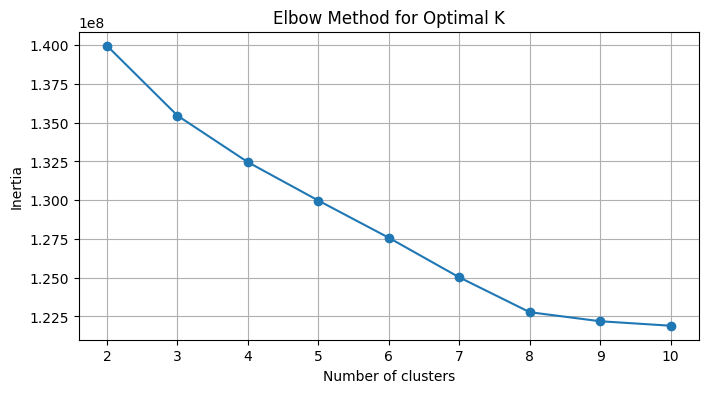

In [26]:
# Elbow method to choose K
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(azdias_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid()
plt.show()

In [ ]:
# Based on elbow, choose optimal K (7)
optimal_k = 7
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
azdias_clusters = kmeans.fit_predict(azdias_pca)
customers_clusters = kmeans.predict(customers_pca)
print(f'Clustering completed with K={optimal_k}')

Clustering completed with K=7


---
## Step 6: Customer Mapping & Comparison

In [28]:
# Calculate cluster proportions
azdias_counts = pd.Series(azdias_clusters).value_counts(normalize=True).sort_index()
customers_counts = pd.Series(customers_clusters).value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'Population': azdias_counts,
    'Customers': customers_counts
}).fillna(0)

comparison['Difference'] = comparison['Customers'] - comparison['Population']
print(comparison)

   Population  Customers  Difference
0    0.147126   0.464790    0.317664
1    0.200683   0.242529    0.041846
2    0.005860   0.021989    0.016129
3    0.107488   0.011164   -0.096324
4    0.243121   0.205431   -0.037690
5    0.151432   0.041240   -0.110192
6    0.144290   0.012858   -0.131432


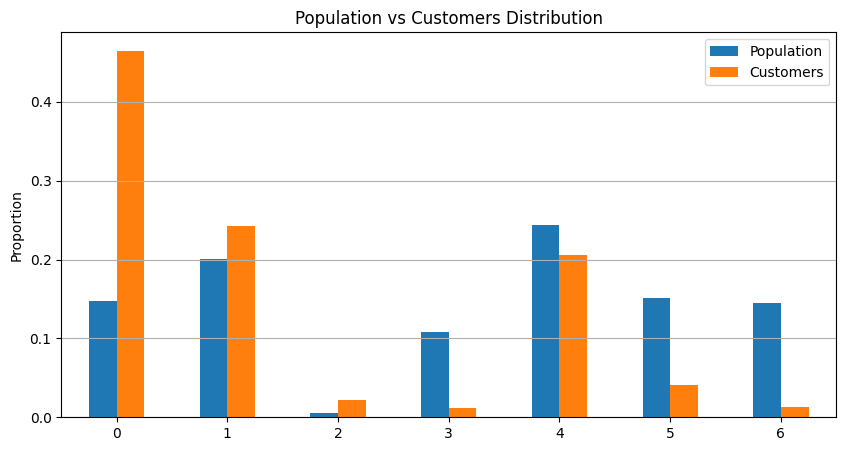

In [29]:
# Plot comparison
comparison[['Population', 'Customers']].plot(kind='bar', figsize=(10,5))
plt.title('Population vs Customers Distribution')
plt.ylabel('Proportion')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

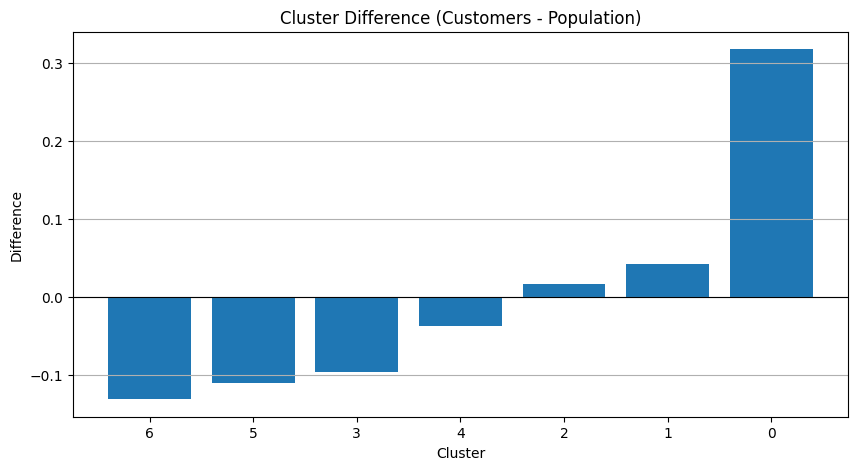

In [30]:
# Plot difference
plt.figure(figsize=(10,5))
comparison_sorted = comparison.sort_values('Difference')
plt.bar(comparison_sorted.index.astype(str), comparison_sorted['Difference'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Cluster Difference (Customers - Population)')
plt.xlabel('Cluster')
plt.ylabel('Difference')
plt.grid(axis='y')
plt.show()

---
## Step 7: Market Profiling

In [31]:
# Identify best cluster (most overrepresented among customers)
best_cluster = comparison['Difference'].idxmax()
print(f'Best cluster (most overrepresented): {best_cluster}')

cluster_data = azdias_clean[azdias_clusters == best_cluster]
top_features = cluster_data.mean().sort_values(ascending=False).head(10)
print('\nTop features of best cluster:')
print(top_features)

Best cluster (most overrepresented): 0

Top features of best cluster:
MIN_GEBAEUDEJAHR       1993.221478
KBA13_ANZAHL_PKW        694.945350
LP_LEBENSPHASE_FEIN      25.545287
WOHNDAUER_2008            8.518342
LP_LEBENSPHASE_GROB       7.409570
ORTSGR_KLS9               5.244948
SEMIO_LUST                5.038165
SEMIO_ERL                 4.958137
SEMIO_VERT                4.762685
INNENSTADT                4.698264
dtype: float64


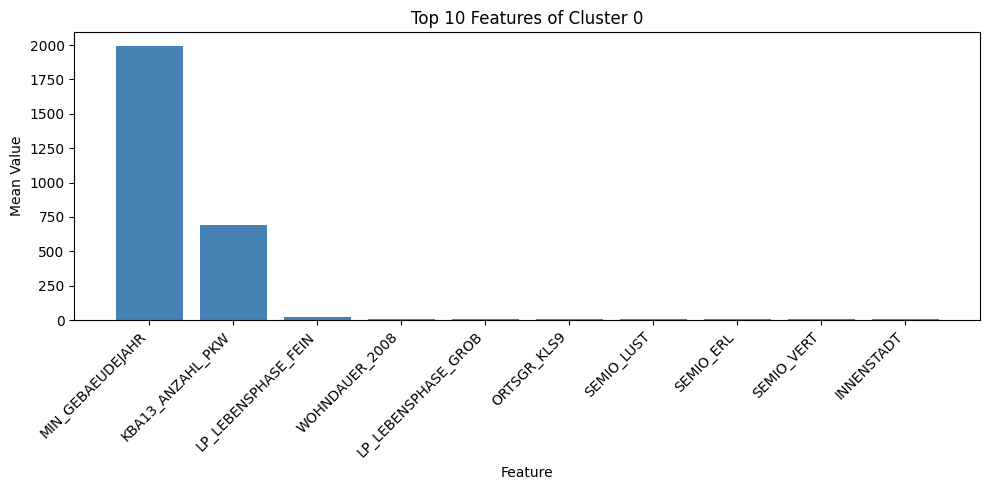

In [32]:
# Visualize top features
plt.figure(figsize=(10,5))
plt.bar(top_features.index, top_features.values, color='steelblue')
plt.title(f'Top 10 Features of Cluster {best_cluster}')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

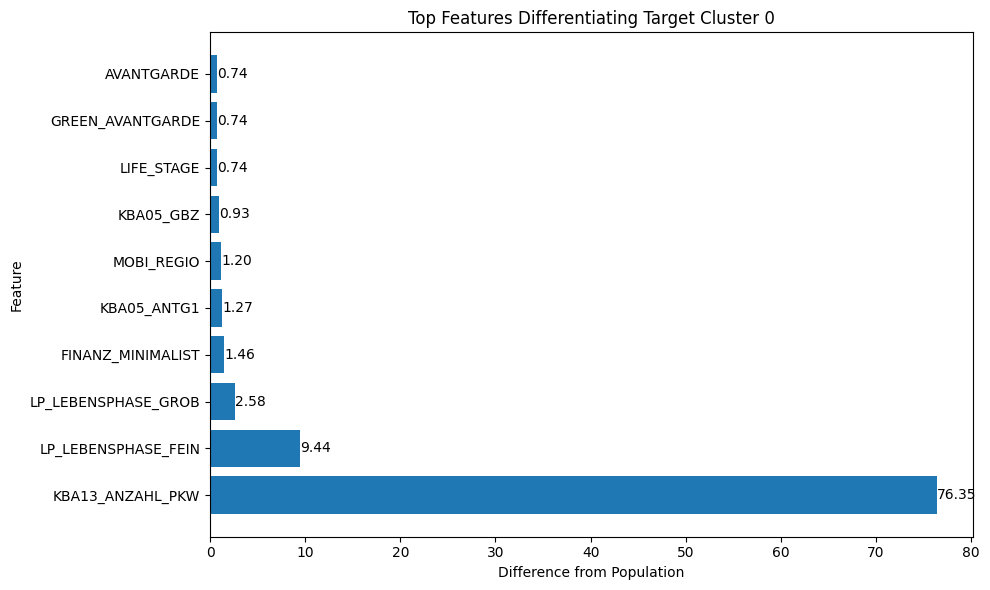

In [36]:
# Compare cluster vs population
population_mean = azdias_clean.mean()
cluster_mean = azdias_clean[azdias_clusters == best_cluster].mean()

comparison_df = pd.DataFrame({
    'Cluster': cluster_mean,
    'Population': population_mean
})

# Difference
comparison_df['Difference'] = comparison_df['Cluster'] - comparison_df['Population']

# Top differences
top_diff = comparison_df['Difference'].sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_diff.index, top_diff.values)

plt.title(f'Top Features Differentiating Target Cluster {best_cluster}')
plt.xlabel('Difference from Population')
plt.ylabel('Feature')

for i, v in enumerate(top_diff.values):
    plt.text(v, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

In [33]:
# Identify worst cluster (most underrepresented among customers)
worst_cluster = comparison['Difference'].idxmin()
print(f'Worst cluster (most underrepresented): {worst_cluster}')

Worst cluster (most underrepresented): 6


In [34]:
worst_cluster_data = azdias_clean[azdias_clusters == worst_cluster]

worst_top_features = worst_cluster_data.mean().sort_values(ascending=False).head(10)

print('\nTop features of worst cluster:')
print(worst_top_features)


Top features of worst cluster:
MIN_GEBAEUDEJAHR       1992.604112
KBA13_ANZAHL_PKW        563.965497
ANZ_HAUSHALTE_AKTIV      13.515605
LP_LEBENSPHASE_FEIN      10.504904
WOHNDAUER_2008            7.286681
ORTSGR_KLS9               6.527080
SEMIO_DOM                 6.062786
SEMIO_KAEM                6.032748
SEMIO_PFLICHT             5.859609
SEMIO_RAT                 5.858349
dtype: float64


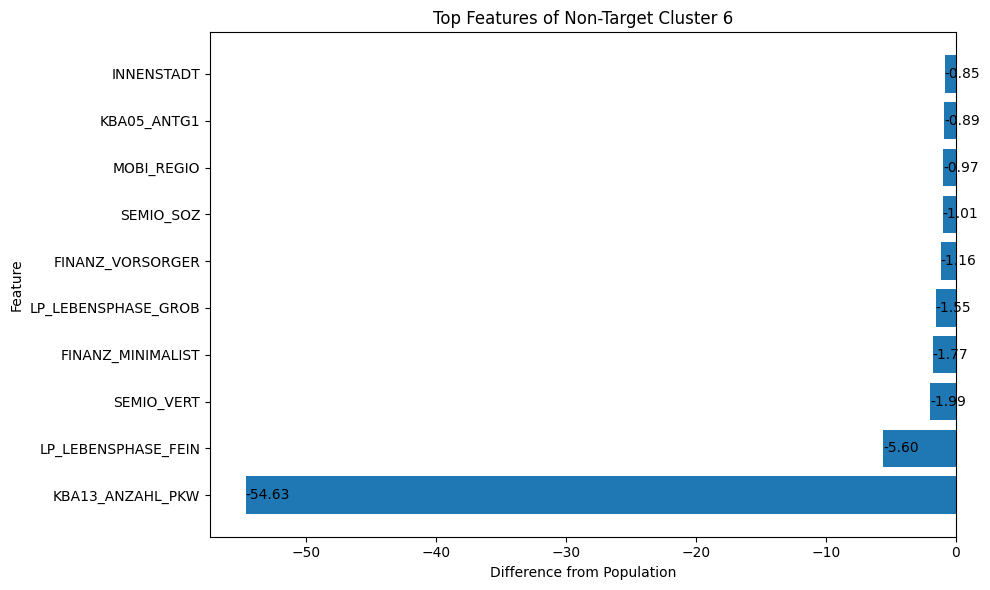

In [35]:
# Compare with population
population_mean = azdias_clean.mean()
worst_cluster_mean = worst_cluster_data.mean()

comparison_worst = pd.DataFrame({
    'Cluster': worst_cluster_mean,
    'Population': population_mean
})

comparison_worst['Difference'] = comparison_worst['Cluster'] - comparison_worst['Population']

# Get most negative differences
bottom_diff = comparison_worst['Difference'].sort_values().head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(bottom_diff.index, bottom_diff.values)

plt.title(f'Top Features of Non-Target Cluster {worst_cluster}')
plt.xlabel('Difference from Population')
plt.ylabel('Feature')

for i, v in enumerate(bottom_diff.values):
    plt.text(v, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

---
## Conclusion

The analysis identified 7 distinct customer segments.

Cluster 0 is the most over-represented among customers, characterized by:
- Significantly higher car density (KBA13_ANZAHL_PKW, +76.35 above population mean)
- Higher life stage scores (LP_LEBENSPHASE_FEIN, +9.44)
- Higher mobility index (MOBI_REGIO, +1.20)
- Avantgarde and green lifestyle orientation (AVANTGARDE, GREEN_AVANTGARDE, +0.74)

This suggests the core customer base consists of suburban/rural residents
with high car ownership, mature life stage, and a progressive lifestyle profile.

Cluster 6 represents the least likely customers — urban, car-free,
financially disengaged residents with a difference of -54.63 in car density.